In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import numpy as np
import os
ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")


import sys
from pathlib import Path

project_root = Path.cwd().parents[0]
sys.path.append(str(project_root))

import aymansigmri as asm

## Notes
- Last attempt did't work due to the nufft adjoint operation presumably causing a loss of information
- As per toby's suggestion - no need to go back and forth through operations
- Therefore proceed as follows:

1. Take the ZTE data from radial to cartesian k-space
2. Make a note of the missing in the centre via a mask
    - This may require some extra work due to kernel smoothing
3. Perform hankel -> SVD and inverse
4. Replace all except inner most region (i.e. that was sampled)



### Currently no way to know exactly where the dead time gap is in cartesian. Needed for few reasons
1. Direct comparision with ground truth data
2. Replacement/data concistency step

In [3]:
gap = 3
zte_radialkspace, zte_radialcoords, radialkspace, radialcoords, mask = asm.generate_zte_data(ksp=ksp, coord=coord, n_missing=gap, undersampling_factor=1)

zte_radial_kspace, zte_radial_coords, full_zte_radial_kspace, full_zte_radial_coords, zte_mask, groundtruth_radial, n_points_full = asm.generate_zte_data_trial(ksp=ksp, coord=coord, n_missing=gap, undersampling_factor=1)


cartesian_zte = asm.nufft_gridding(kspace=full_zte_radial_kspace, coords=full_zte_radial_coords)

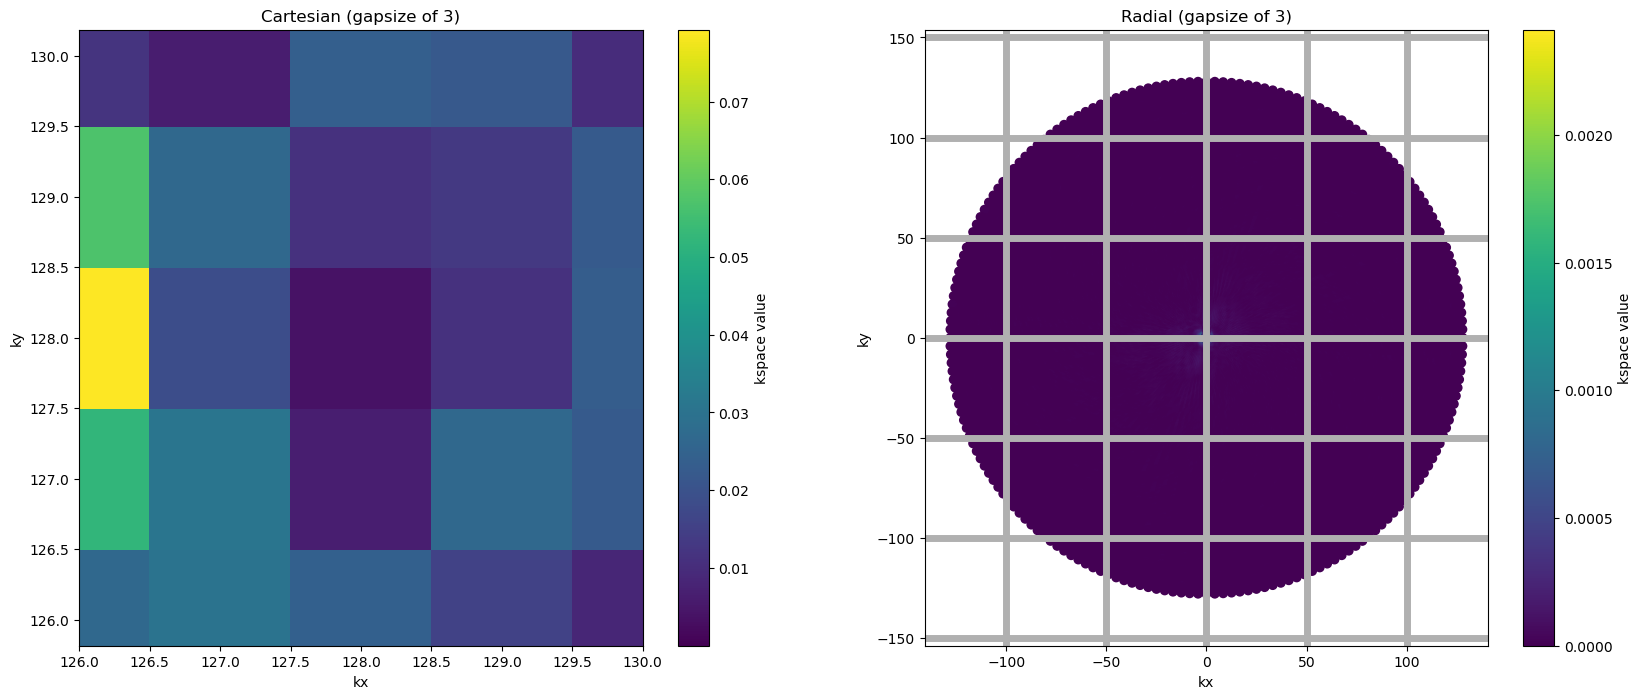

In [ ]:
all_coords = full_zte_radial_coords.reshape(-1, 2)

fig, ax = plt.subplots(nrows=1,ncols=2, figsize=(20,8))


im = ax[0].imshow(np.abs(cartesian_zte[0]), cmap='viridis', origin='lower')
fig.colorbar(im, ax=ax[0], label='kspace value')

ax[0].set_title('Cartesian (gapsize of 3)')
ax[0].set_xlabel('kx')
ax[0].set_ylabel('ky')
ax[0].axis('equal')
'''ax[0].set_xlim(256/2 - 2,256/2 + 2)
ax[0].set_ylim(256/2 - 2,256/2 + 2)'''
'''ax[0].grid(visible=True, linewidth=5)
ax[0].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[0].yaxis.set_major_locator(plt.MultipleLocator(1))'''


im1 = ax[1].scatter(all_coords[:, 1], all_coords[:, 0], c=np.abs(full_zte_radial_kspace[0]), cmap='viridis')
#im1 = ax[1].imshow(np.abs(zte_radialkspace[0]), cmap='viridis', origin='lower')
fig.colorbar(im1, ax=ax[1], label='kspace value')x
ax[1].set_title('Radial (gapsize of 3)')
ax[1].set_xlabel('kx')
ax[1].set_ylabel('ky')
ax[1].axis('equal')
ax[1].grid(visible=True, linewidth=5)
'''ax[1].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1].yaxis.set_major_locator(plt.MultipleLocator(1))

ax[1].set_xlim(0 - 3,0 + 3)
ax[1].set_ylim(0 - 3,0 + 3)'''
plt.show()

## Trying to build the mask
- Want this to generalise for more than one instance
- Struggling to get this right at the moment

[[16. 39. 40. 17.]
 [41. 96. 96. 39.]
 [38. 96. 96. 40.]
 [17. 41. 38. 18.]]
[[ 1. 23. 24.  1.]
 [24. 96. 96. 23.]
 [23. 96. 96. 24.]
 [ 1. 24. 23.  1.]]
[[False  True  True False]
 [ True  True  True  True]
 [ True  True  True  True]
 [False  True  True False]]


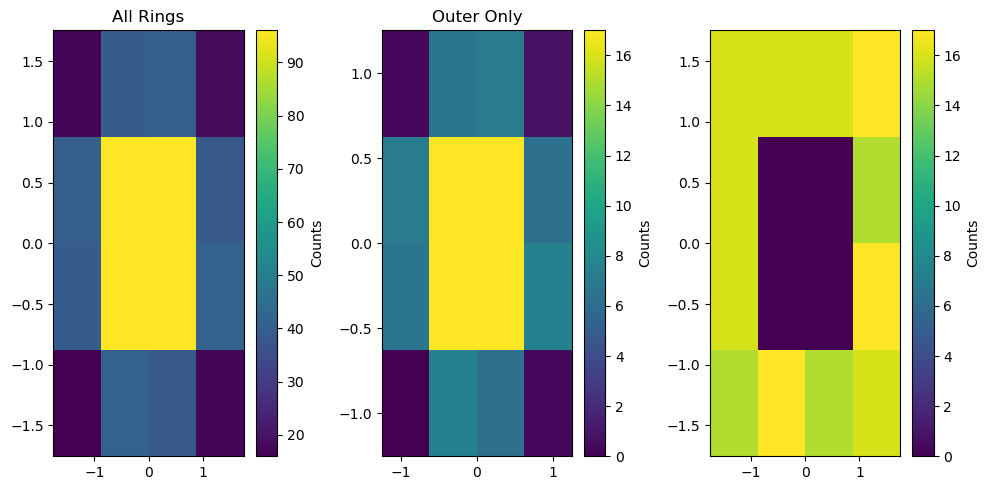

In [5]:
cart_x, cart_y = cartesian_zte.shape[1], cartesian_zte.shape[2]
n_spokes, n_points  = zte_radialcoords.shape[0], zte_radialcoords.shape[1]


cartesian_mask = np.ones((cart_x, cart_y),dtype=bool)


point_labels = np.ones((n_points, n_spokes), dtype=bool)
point_labels[:, gap:] = True

total_count = np.zeros((cart_x, cart_y), dtype=int)
gap_count   = np.zeros((cart_x, cart_y), dtype=int)





rings = []

for point in range(gap):
    ring = full_zte_radial_coords[:,point,:]
    rings.append(ring)
rings = np.array(rings)
n_ingap = n_spokes*rings.shape[0]
list = np.reshape(rings, (n_ingap, 2))
rounded = np.round(list).astype(int)
result = np.hstack([list, rounded])

#add flag - True if from gap
boolean = np.ones((len(result), 1), dtype=bool)
result = np.hstack([result, boolean])

#now get ones from first circle outside of gap
extra_ring = full_zte_radial_coords[:, gap, :]
extra_ring = np.array(extra_ring).reshape(-1,2)
rounded_extra = np.round(extra_ring).astype(int)
result_extra = np.hstack([extra_ring, rounded_extra])

#add flag to extra ring
boolean_extra = np.zeros((len(rounded_extra), 1), dtype=bool)
result_extra = np.hstack([result_extra, boolean_extra])

final = np.vstack([result, result_extra])


### Few notes about final
# col 1 - kx val
# col 2 - ky val
# col 3 - kx rounded
# col 4 - ky rounded
# col 5 - 1 if from gap, 0 if aquired

dtg_coverage = (np.max(final[:,2]) - np.min(final[:,2])).astype(int)

H, xedges, yedges = np.histogram2d(final[:,0], final[:,1], bins=dtg_coverage)

gap_points = final[final[:,4] == 1]  # rows where is_gap flag is True

nongap_points = final[final[:,4] == 0]  # rows where is_gap flag is True


H_gap, _, _ = np.histogram2d(gap_points[:,0], gap_points[:,1], bins=(xedges, yedges))

gap_fraction = np.where(H > 0, H_gap / H > 0.5, True)


print(H)
print(H_gap)
print(gap_fraction)
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10,5))

_, _, _, img0 = ax[0].hist2d(final[:,0], final[:,1], bins=dtg_coverage)
ax[0].set_title('All Rings')

_, _, _, img1 = ax[1].hist2d(gap_points[:,0], gap_points[:,1], bins=dtg_coverage)
ax[1].set_title('Gap Only')

_, _, _, img1 = ax[2].hist2d(nongap_points[:,0], nongap_points[:,1], bins=dtg_coverage)
ax[1].set_title('Outer Only')

fig.colorbar(img0, ax=ax[0], label='Counts')
fig.colorbar(img1, ax=ax[1], label='Counts')
fig.colorbar(img1, ax=ax[2], label='Counts')

plt.tight_layout()
plt.show()

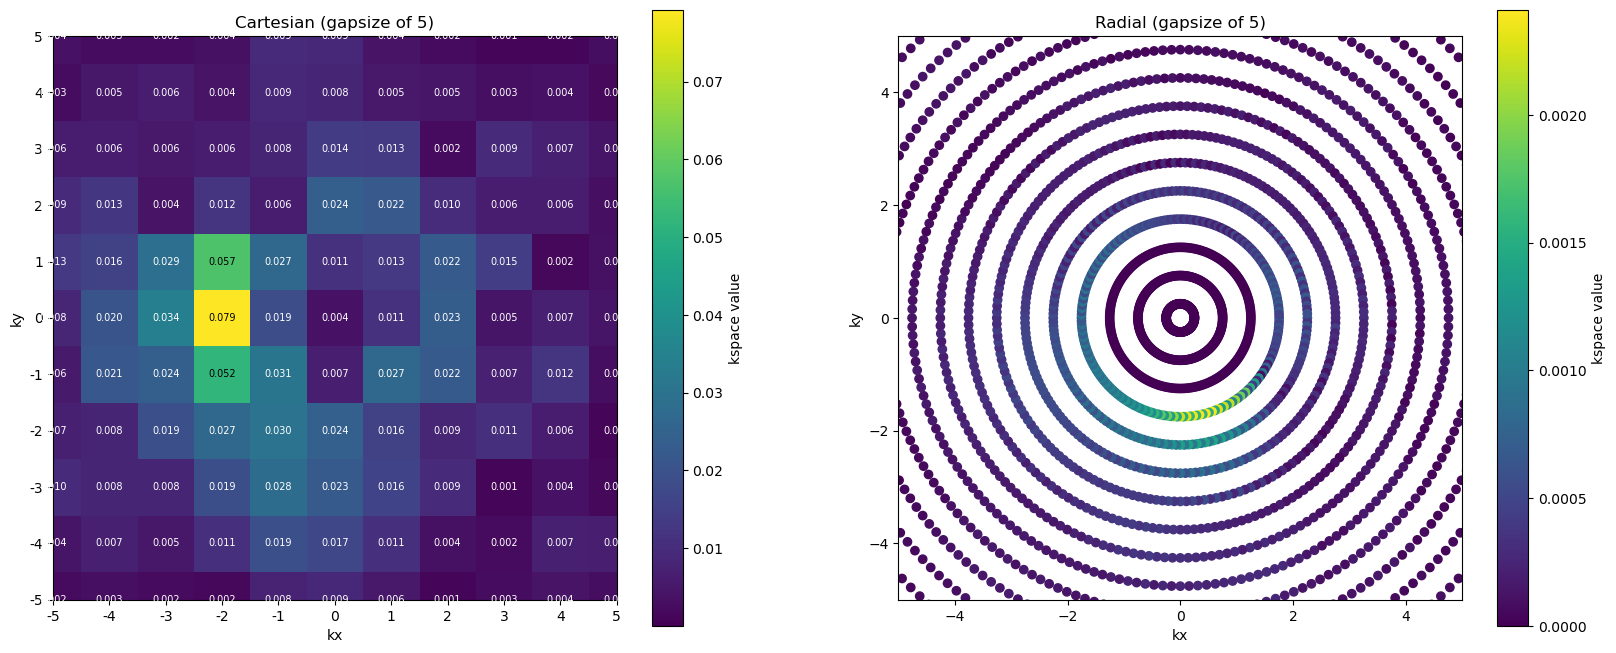

In [6]:
N = cartesian_zte.shape[-1]  # 256

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))

im = ax[0].imshow(np.abs(cartesian_zte[0]), cmap='viridis', origin='lower')
fig.colorbar(im, ax=ax[0], label='kspace value')

ax[0].set_title('Cartesian (gapsize of 5)')
ax[0].set_xlabel('kx')
ax[0].set_ylabel('ky')
ax[0].set_xlim(N//2 - 5, N//2 + 5)
ax[0].set_ylim(N//2 - 5, N//2 + 5)
ax[0].set_aspect('equal')

tick_pixels = np.arange(N//2 - 5, N//2 + 6)
tick_labels = tick_pixels - N//2

ax[0].set_xticks(tick_pixels)
ax[0].set_xticklabels(tick_labels)
ax[0].set_yticks(tick_pixels)
ax[0].set_yticklabels(tick_labels)

vmax = np.abs(cartesian_zte[0]).max()
for iy in range(N//2 - 5, N//2 + 6):
    for ix in range(N//2 - 5, N//2 + 6):
        val = np.abs(cartesian_zte[0, iy, ix])
        color = 'black' if val > vmax / 2 else 'white'
        ax[0].text(ix, iy, f'{val:.3f}', ha='center', va='center', fontsize=7, color=color)

im1 = ax[1].scatter(all_coords[:, 0], all_coords[:, 1], c=np.abs(full_zte_radial_kspace[0]), cmap='viridis')
fig.colorbar(im1, ax=ax[1], label='kspace value')
ax[1].set_title('Radial (gapsize of 5)')
ax[1].set_xlabel('kx')
ax[1].set_ylabel('ky')
ax[1].set_aspect('equal')
ax[1].set_xlim(-5, 5)
ax[1].set_ylim(-5, 5)

plt.show()

# Next Steps
- Test with different gap sizes and 'spoke legnths'
    - Consider how to do this now we are no longer usings spokes
- Build full analysis pipeline to compare optimal amount of information to put into the process via l2 norm minimisation

In [7]:
gap = 1
zte_radial_kspace, zte_radial_coords, full_zte_radial_kspace, full_zte_radial_coords, zte_mask, groundtruth_radial, n_points_full = asm.generate_zte_data_trial(ksp=ksp, coord=coord, n_missing=gap, undersampling_factor=1)

cartesian_zte = asm.nufft_gridding(kspace=full_zte_radial_kspace, coords=full_zte_radial_coords)

cart_x, cart_y = cartesian_zte.shape[1], cartesian_zte.shape[2]

mask = np.ones((cart_x, cart_y), dtype=bool)
mask[127:129, 127:129] = False
print(mask[126:130, 126:130])



[[ True  True  True  True]
 [ True False False  True]
 [ True False False  True]
 [ True  True  True  True]]


In [8]:
def cartesian_data_consistency(kspace_cartsvd, kspace_cartacquired, halfmask_width):
    size = kspace_cartsvd[0,0].shape[0]
    cart_mask = np.ones((size, size),dtype=bool)
    
    cen_x, cen_y = size // 2, size // 2
    cart_mask[cen_x - halfmask_width:cen_x + halfmask_width, cen_y - halfmask_width: cen_y + halfmask_width] = False

    cartesian_kspace_consistent = kspace_cartsvd.copy()

    for coil in range(kspace_cartsvd.shape[0]):
        cartesian_kspace_consistent[coil][cart_mask] = kspace_cartacquired[coil][cart_mask]

    return cartesian_kspace_consistent, cart_mask

def im_recon_cart(kspace, save_path=None):
    grid_recon = sp.ifft(kspace)
    im_rss_recon = np.sum(np.abs(grid_recon)**2, axis=0)**0.5
    fig = pl.ImagePlot(im_rss_recon)
    if save_path:
        fig.savefig(save_path)

In [9]:
cart_x, cart_y = cartesian_zte.shape[1], cartesian_zte.shape[2]

mask = np.ones((cart_x, cart_y), dtype=bool)
mask[127:129, 127:129] = False

print(mask[126:130, 126:130])

[[ True  True  True  True]
 [ True False False  True]
 [ True False False  True]
 [ True  True  True  True]]


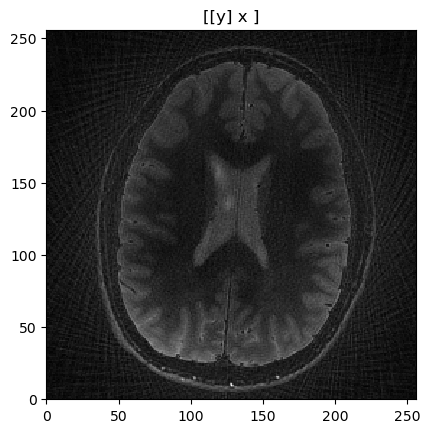

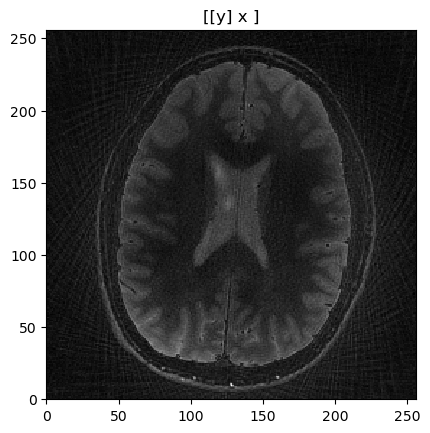

KeyboardInterrupt: 

In [10]:
gap = 2
zte_radial_kspace, zte_radial_coords, full_zte_radial_kspace, full_zte_radial_coords, zte_mask, groundtruth_radial, n_points_full = asm.generate_zte_data_trial(ksp=ksp, coord=coord, n_missing=gap, undersampling_factor=1)

cartesian_zte = asm.nufft_gridding(kspace=full_zte_radial_kspace, coords=full_zte_radial_coords)




win = 5

n_iters = 10
iter_count = 0
asm.im_recon_cart(kspace=cartesian_zte)
while iter_count < n_iters:
    
    hankel_matrix, n_coils, Numx, Numy = asm.hankel(kspace=cartesian_zte, w=win)

    U, S_reduced, Vh = asm.sig_val_thresholding(data=hankel_matrix, zero_thresh=0.5)
    data_recon = (U * S_reduced) @ Vh

    kspace_cart_coils_recon = asm.hankel_H(data_recon, n_coils=cartesian_zte.shape[0], Nx=cartesian_zte.shape[1], Ny=cartesian_zte.shape[2], w=win)

    kspace_cart_coils_consistent = kspace_cart_coils_recon

    for coil in range(cartesian_zte.shape[0]):
        kspace_cart_coils_consistent[coil][mask] = cartesian_zte[coil][mask]

    iter_count += 1
    grid_recon = sp.ifft(kspace_cart_coils_consistent)
    im_rss_recon = np.sum(np.abs(grid_recon)**2, axis=0)**0.5
    pl.ImagePlot(im_rss_recon)
    cartesian_zte = kspace_cart_coils_consistent